# Structural Balance and Relationship Inertia in Networks of Nations
**CITS4403 Research Project: analysis notebook**

**Research question.** Under what conditions does a network of nations settle into at most two stable opposing blocs, and does the entrenchment of relationships (relationship inertia) change how much random disruption the network can absorb?

This notebook walks through the data, the model, the experiments and the results. Every number and figure comes from the code and result files in this repository. **All country identities are anonymised**: countries appear only as `Nation_1 ... Nation_N`.

**Contents:** 1. Model · 2. Data · 3. The model in action · 4. A live mini-experiment · 5. Results · 6. The geography extension · 7. The map · 8. Does the main model's result survive? · 9. What geography actually changes · 10. Discussion and limitations · 11. Reproducing everything

In [1]:
import csv
import os
import sys

# find the project root (the folder containing src/) so the notebook runs from anywhere
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "src")) and ROOT != os.path.dirname(ROOT):
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

import matplotlib.pyplot as plt
import networkx as nx

import balance_model as bm
import data_pipeline as dp
from blocs import analyse_blocs


## 1. The model

**Structural balance theory** (Heider, 1946; Cartwright and Harary, 1956) says that relationships tend to become consistent: a friend of my friend is my friend, and an enemy of my enemy is my friend. Countries are nodes and each relationship $(i,j)$ has a sign $s_{ij}=+1$ (cooperative) or $-1$ (hostile).

A triangle of three countries is **balanced** when

$$s_{ij}\,s_{jk}\,s_{ik}=+1,$$

that is, when it has an even number of hostile relationships. Antal, Krapivsky and Redner (2005) studied the local dynamics: repeatedly pick an unbalanced triangle and flip one of its relationships. Flipping any single relationship of an unbalanced triangle always makes it balanced. A network with no unbalanced triangle settles into one bloc or exactly two.

**What we add.**

* **Noise.** At each step, with probability $\epsilon$, a random relationship of the chosen triangle flips regardless of balance (a random shock).
* **Relationship inertia.** Each relationship has an inertia $\iota_{ij}\in[0,0.9]$. When it is chosen to flip, it resists with probability $\iota_{ij}$. Inertia comes from real coverage: with $m_{ij}$ news mentions of the pair and $m_{\max}$ the largest count,

$$\iota_{ij}=0.9\,\frac{\ln(1+m_{ij})}{\ln(1+m_{\max})}.$$

Mention counts are heavy-tailed, so the logarithm keeps small counts from collapsing to zero.

A run has **settled** when there is no unbalanced triangle for 800 consecutive steps. It is **globally consistent** when the whole network can be split into at most two groups with cooperative relationships inside and hostile ones between. These are not the same thing on a network with missing relationships (Section 5).

## 2. Data

The starting networks come from [GDELT](https://www.gdeltproject.org/), a public news-event database. For each of two days (4 and 6 October 2026) we aggregated one export file per hour into one row per country pair: mean tone of the coverage and number of mentions. We keep the **8 countries with the most mentions**, set each relationship's sign by comparing its tone with the **median tone among those countries** (news tone skews negative, so a cut-off of zero would make almost everything hostile), and anonymise the labels.

The cell below summarises both networks. In the drawings, green edges are cooperative, red are hostile, and thicker edges have more inertia.

Day 1 (4 Oct): 8 nations, 20 relationships (71% of possible), 10 cooperative / 10 hostile, 22 triangles, median inertia 0.57
Day 2 (6 Oct): 8 nations, 25 relationships (89% of possible), 12 cooperative / 13 hostile, 40 triangles, median inertia 0.57


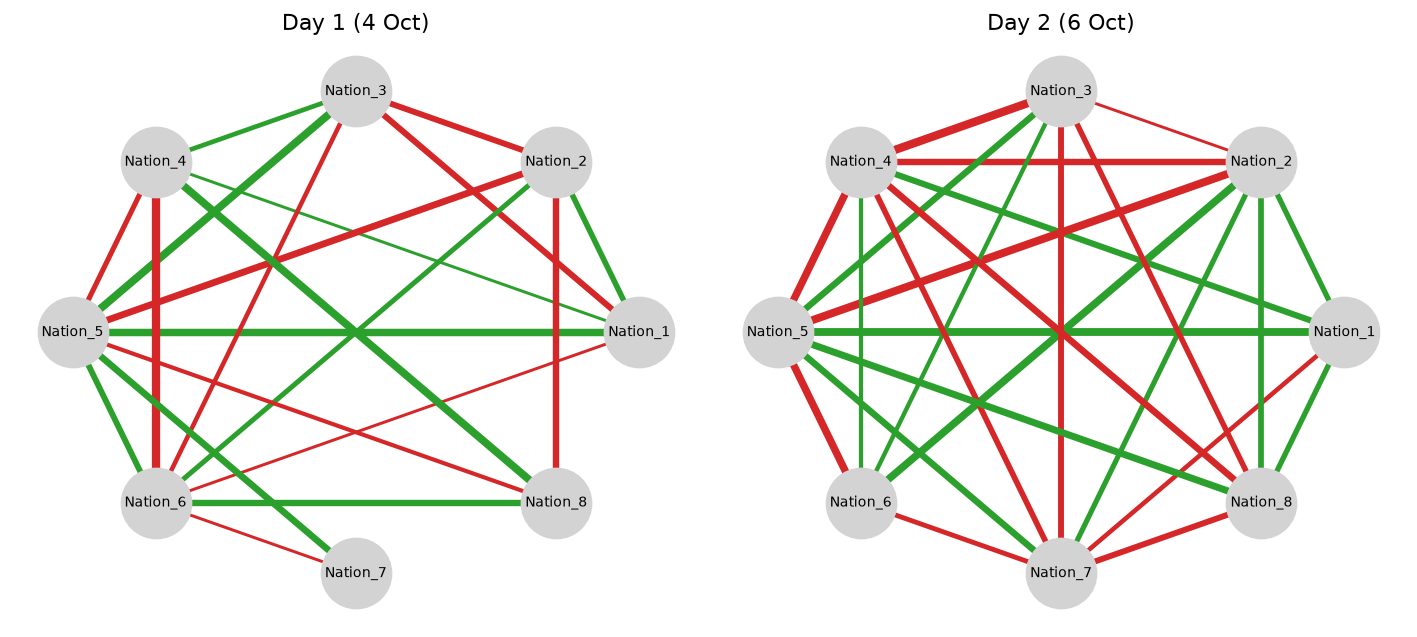

In [2]:
SNAPSHOTS = {"Day 1 (4 Oct)": "data/country_relationships.csv",
             "Day 2 (6 Oct)": "data/country_relationships_day2.csv"}
networks = {label: dp.load_and_build(path, n_countries=8)[0] for label, path in SNAPSHOTS.items()}

for label, G in networks.items():
    s = dp.summarise(G)
    print(f"{label}: {s['nodes']} nations, {s['edges']} relationships ({s['density']:.0%} of possible), "
          f"{s['positive_edges']} cooperative / {s['negative_edges']} hostile, {s['triangles']} triangles, "
          f"median inertia {s['inertia_median']:.2f}")

def draw(G, ax, title):
    pos = nx.circular_layout(G)
    colours = ["tab:green" if d["sign"] == 1 else "tab:red" for _, _, d in G.edges(data=True)]
    widths = [1 + 4 * d["inertia"] for _, _, d in G.edges(data=True)]
    nx.draw_networkx(G, pos, ax=ax, edge_color=colours, width=widths,
                     node_color="lightgray", node_size=1500, font_size=8)
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, G) in zip(axes, networks.items()):
    draw(G, ax, label)
plt.tight_layout()
plt.show()

## 3. The model in action

One simulation on the day-1 network, starting from the real signs, with the same random seed in every condition. The curve shows the fraction of balanced triangles over time. A run that reaches 1.0 and stays there has settled.

No noise: settled=True, globally consistent=True, number of blocs=2


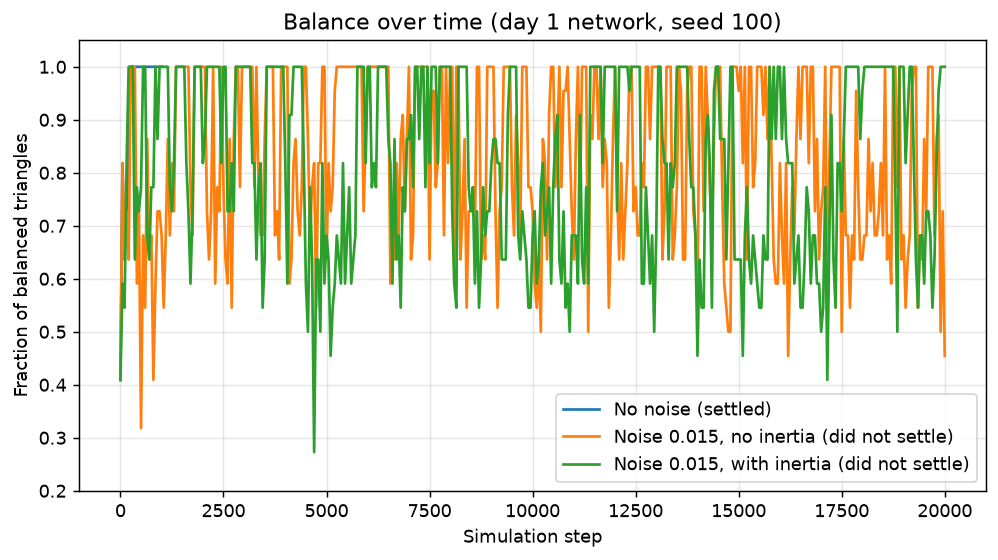

In [3]:
G1 = networks["Day 1 (4 Oct)"]
conditions = [("No noise", 0.0, False),
              ("Noise 0.015, no inertia", 0.015, False),
              ("Noise 0.015, with inertia", 0.015, True)]

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, noise, use_inertia in conditions:
    _, history, settled = bm.run_simulation(G=G1.copy(), noise=noise, max_steps=20000,
                                            converge_patience=800, seed=100, use_inertia=use_inertia)
    steps, ratios = zip(*history)
    ax.plot(steps, ratios, label=f"{label} ({'settled' if settled else 'did not settle'})")
ax.set(xlabel="Simulation step", ylabel="Fraction of balanced triangles", ylim=(0.2, 1.05),
       title="Balance over time (day 1 network, seed 100)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

# What does a settled network look like?  (no noise)
G_end, _, settled = bm.run_simulation(G=G1.copy(), noise=0.0, max_steps=20000,
                                      converge_patience=800, seed=100)
blocs = analyse_blocs(G_end)
print(f"No noise: settled={settled}, globally consistent={blocs['consistent']}, number of blocs={blocs['n_blocs']}")

## 4. A live mini-experiment

Twenty runs at noise 0.015 on the day-1 network, with and without inertia (same seeds). This is a small version of the main experiment in Section 5, which uses 30 repeats and many noise levels.

In [4]:
def settled_count(G, noise, use_inertia, repeats=20, seed0=100):
    return sum(bm.run_simulation(G=G.copy(), noise=noise, max_steps=40000, converge_patience=800,
                                 seed=seed0 + i, use_inertia=use_inertia)[2] for i in range(repeats))

for use_inertia in (False, True):
    k = settled_count(G1, 0.015, use_inertia)
    print(f"noise 0.015, {'with' if use_inertia else 'without'} inertia: {k} of 20 runs settled")

noise 0.015, without inertia: 0 of 20 runs settled
noise 0.015, with inertia: 19 of 20 runs settled


## 5. Results

All results below were produced by `src/run_experiments.py` (30 repeats per condition, fixed seeds, 95% Wilson intervals for proportions). Each snapshot gives one fixed starting network, so the repeats vary only the random dynamics.

### 5.1 Noise and inertia

day1_n8: fraction of runs that settled (95% interval)
noise   without inertia           with inertia
0.01    0.67 (0.49-0.81)          1.00 (0.89-1.00)
0.015   0.03 (0.01-0.17)          0.97 (0.83-0.99)
0.02    0.07 (0.02-0.21)          0.50 (0.33-0.67)

day2_n8: fraction of runs that settled (95% interval)
noise   without inertia           with inertia
0.01    0.37 (0.22-0.54)          0.93 (0.79-0.98)
0.015   0.03 (0.01-0.17)          0.63 (0.46-0.78)
0.02    0.00 (0.00-0.11)          0.27 (0.14-0.44)



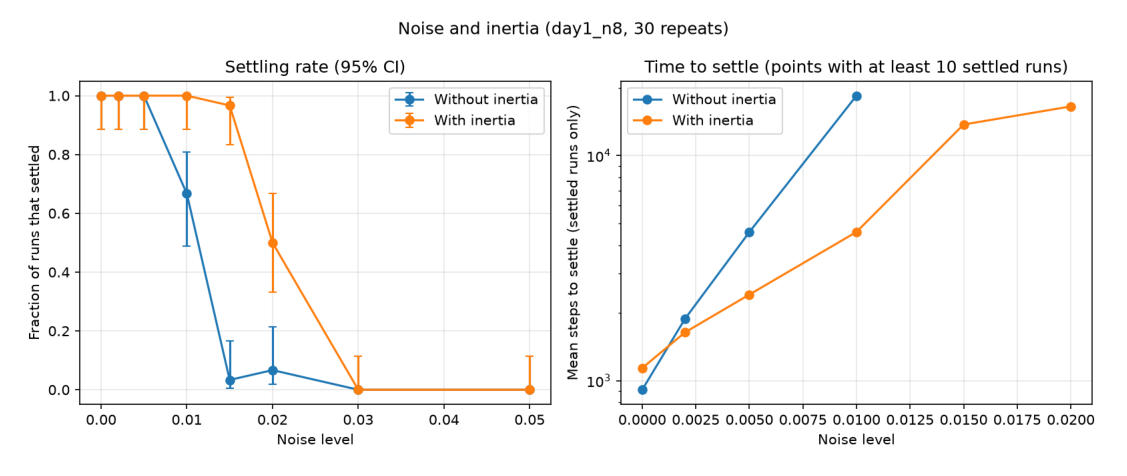

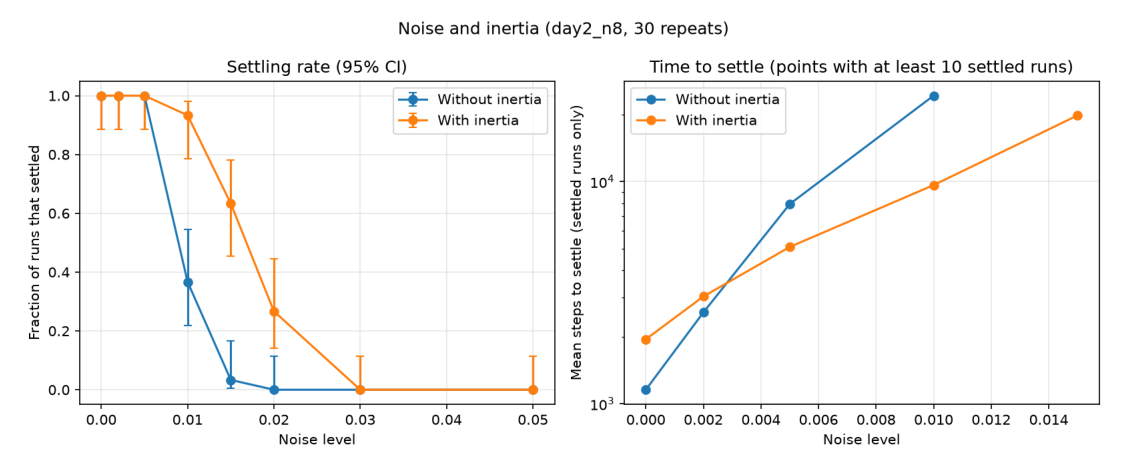

In [5]:
def show(name, width=11):
    path = f"results/{name}.png"
    if not os.path.exists(path):
        print(f"{path} not found: run `python src/run_experiments.py` first")
        return
    img = plt.imread(path)
    plt.figure(figsize=(width, width * img.shape[0] / img.shape[1]))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

def settling_table(tag, levels=(0.01, 0.015, 0.02)):
    rows = list(csv.DictReader(open(f"results/noise_{tag}.csv")))
    print(f"{tag}: fraction of runs that settled (95% interval)")
    print(f"{'noise':<8}{'without inertia':<26}with inertia")
    for level in levels:
        cell = {r["inertia"]: f"{float(r['conv_rate']):.2f} ({float(r['conv_lo']):.2f}-{float(r['conv_hi']):.2f})"
                for r in rows if abs(float(r["noise"]) - level) < 1e-9}
        print(f"{level:<8}{cell['False']:<26}{cell['True']}")
    print()

settling_table("day1_n8")
settling_table("day2_n8")
show("noise_day1_n8")
show("noise_day2_n8")

**Reading.** Without noise every run settles. As noise grows, the network without inertia stops settling at around 0.01 to 0.015; with inertia it keeps settling up to about 0.015 to 0.02 (at 0.02 only about half of the day-1 runs and a quarter of the day-2 runs settle). The intervals do not overlap at 0.01, 0.015 and 0.02 on either day. At 0.03 and above nothing settles with or without inertia, so inertia postpones the collapse but does not prevent it. The time-to-settle panel shows only noise levels where at least 10 runs settled, because means based on one or two runs are unreliable.

### 5.2 Settling is not the same as forming two blocs

We removed a fraction of the relationships at random (no noise, no inertia) and counted how many settled runs were also globally consistent, i.e. a valid split into at most two blocs.

day1_n8
density   settled   also consistent   mean components
0.71      1.00      1.00              1.00
0.61      1.00      0.80              1.00
0.50      1.00      0.70              1.10
0.39      1.00      0.60              1.27
0.29      1.00      0.83              1.70

day2_n8
density   settled   also consistent   mean components
0.89      1.00      1.00              1.00
0.75      1.00      1.00              1.00
0.64      1.00      0.83              1.00
0.50      1.00      0.37              1.00
0.36      1.00      0.67              1.20



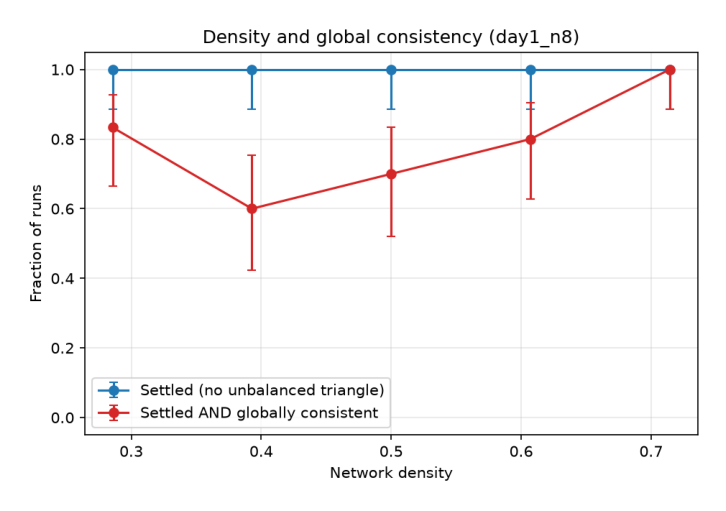

In [6]:
for tag in ("day1_n8", "day2_n8"):
    print(tag)
    print(f"{'density':<10}{'settled':<10}{'also consistent':<18}mean components")
    for r in csv.DictReader(open(f"results/density_{tag}.csv")):
        print(f"{float(r['density']):<10.2f}{float(r['conv_rate']):<10.2f}{float(r['consistent_rate']):<18.2f}{float(r['mean_components']):.2f}")
    print()
show("density_day1_n8", width=7)

**Reading.** Every run settles, but on sparse networks many settled networks are *not* a valid two-bloc split: an unbalanced loop of four or more countries with no closing relationship contains no triangle, so the update rule never sees it. At the real densities (71% and 89% of pairs) every settled network was a valid split. At the lowest densities the network falls apart into several components, and small components are easily consistent, which is why the curve rises again.

### 5.3 Sensitivity to the sign threshold

threshold,day1_n8,False,0.011904761904761904,40
threshold,day1_n8,True,0.02,40
threshold,day1_n8,False,0.01131578947368421,50
threshold,day1_n8,True,0.02,50
threshold,day1_n8,False,0.012045454545454545,60
threshold,day1_n8,True,0.02,60


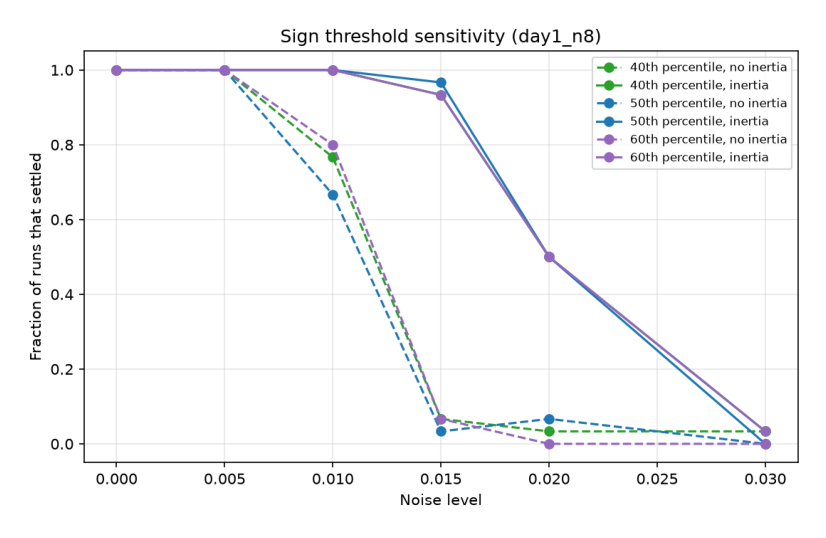

In [7]:
show("threshold_day1_n8", width=8)
for line in open("results/tipping_points.csv"):
    if line.startswith("threshold,day1"):
        print(line.strip())

**Reading.** The 40th, 50th and 60th percentile thresholds give almost the same curves, so the result does not depend on the median choice. (`tipping_points.csv` lists the interpolated noise level at which the settling rate falls below 50%; because the noise grid is coarse, quote settling rates rather than the third decimal of these.)

### 5.4 Controls: what is the inertia doing?

Five arms on the same seeds: no inertia; the real inertia; the same inertia values shuffled across relationships; the same average inertia on every relationship; and shuffled signs with no inertia.

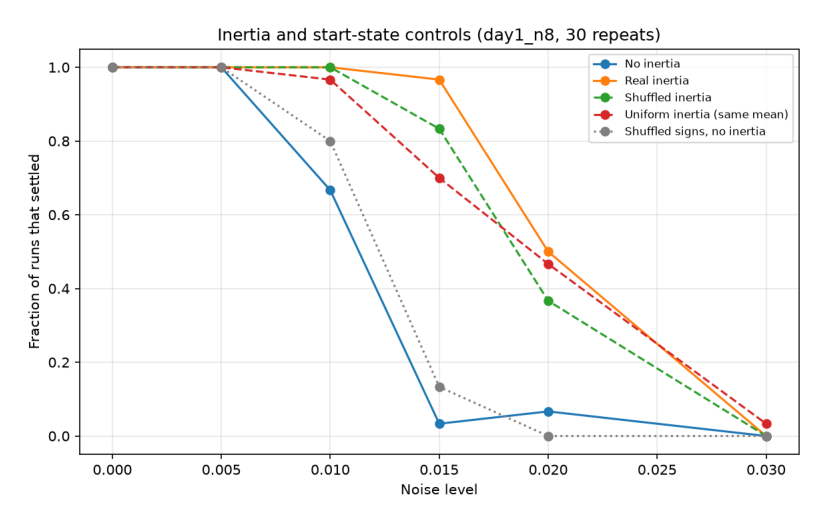

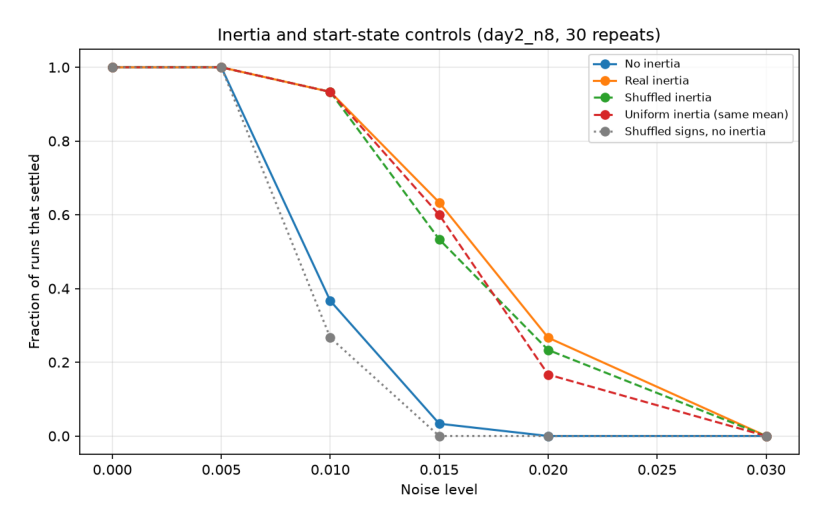

In [8]:
show("control_day1_n8", width=8)
show("control_day2_n8", width=8)

**Reading.** All three inertia variants raise noise tolerance far above the baseline. The real, shuffled and uniform versions are close to each other, and with 30 repeats their intervals overlap, so the data support "added resistance helps" but do not show that *which* relationships are entrenched matters. Shuffled signs behave about like the real signs, in opposite directions on the two days, so there is no evidence that the starting signs affect the noise tolerance.

### 5.5 Are the real signs more balanced than chance?

A permutation test: keep the network structure and the number of cooperative relationships, shuffle which relationships are cooperative 10,000 times, and compare the fraction of balanced triangles.

In [9]:
for tag in ("day1_n8", "day2_n8"):
    for r in csv.DictReader(open(f"results/initial_balance_{tag}.csv")):
        print(f"{tag} percentile {r['percentile']}: real {float(r['observed_balance']):.3f} vs shuffled mean "
              f"{float(r['shuffled_mean_balance']):.3f}  (p more balanced {float(r['p_more_balanced']):.3f}, "
              f"p less balanced {float(r['p_less_balanced']):.3f})")

day1_n8 percentile 40: real 0.318 vs shuffled mean 0.489  (p more balanced 0.967, p less balanced 0.077)
day1_n8 percentile 50: real 0.318 vs shuffled mean 0.500  (p more balanced 0.970, p less balanced 0.067)
day1_n8 percentile 60: real 0.500 vs shuffled mean 0.511  (p more balanced 0.632, p less balanced 0.544)
day2_n8 percentile 40: real 0.400 vs shuffled mean 0.491  (p more balanced 0.912, p less balanced 0.152)
day2_n8 percentile 50: real 0.425 vs shuffled mean 0.503  (p more balanced 0.879, p less balanced 0.199)
day2_n8 percentile 60: real 0.525 vs shuffled mean 0.509  (p more balanced 0.478, p less balanced 0.647)


**Reading.** There is no evidence that the tone-derived signs are more balanced than chance. At the lower thresholds they are, if anything, less balanced, but no p-value is below 0.05 and with only 22 and 40 triangles the test has little power.

## 6. The geography extension

The model above assumes that every pair of nations can hold a relationship. This section adds the layer underneath it: **which pairs can hold a direct relationship at all** is decided by where the nations are and how strong their economies are.

* Every nation sits at a random point on a flat map, $(x,y)\in[0,1]^2$.
* Every nation carries an economic tier: two strong and six weak, assigned in a seeded random order.
* A nation reaches $R_i = r_{min} + \beta\,e_i$ map units, and a pair is **admissible** when $d_{ij} \le R_i + R_j$. A distant pair of weak economies can therefore never hold a direct relationship, while two strong economies can reach across the map.
* The radius $r_{min}$ is calibrated by bisection so that the gate keeps a set share of the real relationships (75% by default). Fixing the radius by hand would give every map draw a different density, and the comparison with a randomly thinned network would no longer be fair.

The extension only ever **removes** relationships: signs and inertia are copied unchanged and no relationship is added. That is why every result in sections 1 to 5 still applies to the network underneath, and why a test can show that a run on a wide-open gate is identical to a run with no geography at all.

In [10]:
import geography as geo
import geo_experiments as gex

G1 = networks["Day 1 (4 Oct)"]
KEEP = gex.DEFAULT_KEEP
r_min = geo.calibrate_r_min(G1, target_keep=KEEP, probes=gex.CALIBRATION_PROBES, seed=100)

substrates = {}
print(f"keep {KEEP:.0%} of the day-1 relationships, reach intercept r_min = {r_min:.3f}\n")
print(f"{'substrate':<11}{'relationships':<15}{'triangles':<11}{'components':<12}"
      f"{'isolated':<10}mean distance")
for kind in gex.SUBSTRATES:
    H, positions, economy, _ = gex.build_substrate(G1, kind, draw_seed=100,
                                                   keep=KEEP, r_min=r_min)
    substrates[kind] = (H, positions, economy)
    s = geo.describe(H, positions)
    print(f"{kind:<11}{s['edges']:<15}{s['triangles']:<11}{s['components']:<12}"
          f"{s['isolated_nodes']:<10}{s['mean_edge_length']:.2f}")

keep 75% of the day-1 relationships, reach intercept r_min = 0.020

substrate  relationships  triangles  components  isolated  mean distance
real       20             22         1           0         0.58
random     15             9          1           0         0.56
geo        15             10         1           0         0.50


## 7. The map

The drawing below places the eight nations where the model puts them. Green edges are cooperative and red are hostile, exactly as in section 2, and the width follows inertia. Faint dashed lines are pairs that the gate makes impossible: they can only be connected through a third country. Node size follows the economic tier. The three panels share one layout, so the only thing that changes is which relationships survive.

the gate makes 5 of 20 relationships impossible


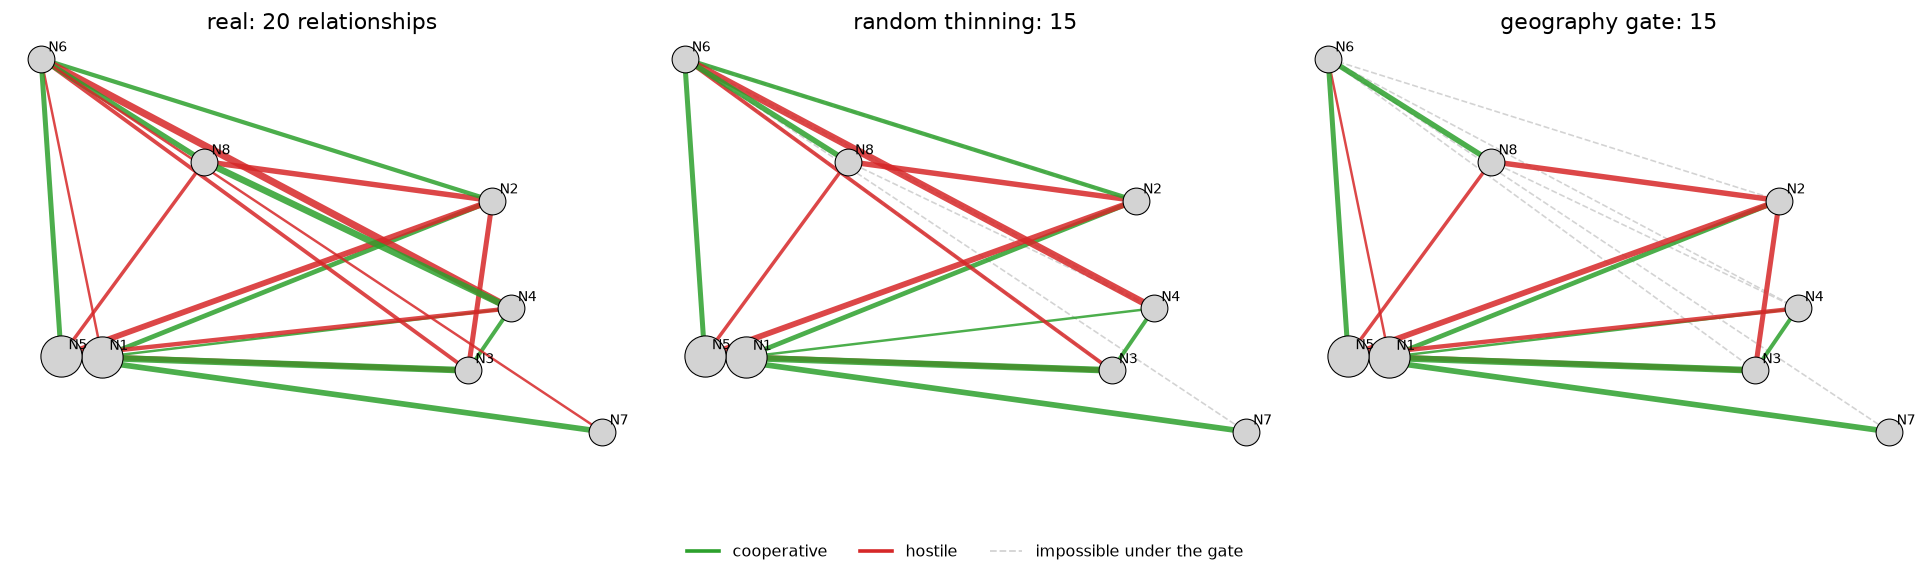

In [11]:
def draw_map(ax, G, positions, economy, title, removed=()):
    for u, v in removed:
        (x1, y1), (x2, y2) = positions[u], positions[v]
        ax.plot([x1, x2], [y1, y2], color="lightgray", linestyle="--",
                linewidth=0.9, zorder=1)
    for u, v, d in G.edges(data=True):
        (x1, y1), (x2, y2) = positions[u], positions[v]
        colour = "tab:green" if d["sign"] == 1 else "tab:red"
        ax.plot([x1, x2], [y1, y2], color=colour,
                linewidth=0.8 + 3.5 * d["inertia"], alpha=0.85,
                solid_capstyle="round", zorder=2)
    for node in G.nodes():
        x, y = positions[node]
        ax.scatter(x, y, s=120 + 400 * economy[node], color="lightgray",
                   edgecolors="black", linewidths=0.6, zorder=3)
        ax.annotate(node.replace("Nation_", "N"), (x, y), xytext=(4, 4),
                    textcoords="offset points", fontsize=8, zorder=4)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


real, real_positions, real_economy = substrates["real"]
random_network, random_positions, random_economy = substrates["random"]
geo_network, geo_positions, geo_economy = substrates["geo"]
impossible = [edge for edge in real.edges() if not geo_network.has_edge(*edge)]
print(f"the gate makes {len(impossible)} of {real.number_of_edges()} relationships impossible")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
draw_map(axes[0], real, real_positions, real_economy,
         f"real: {real.number_of_edges()} relationships")
draw_map(axes[1], random_network, random_positions, random_economy,
         f"random thinning: {random_network.number_of_edges()}", removed=impossible)
draw_map(axes[2], geo_network, geo_positions, geo_economy,
         f"geography gate: {geo_network.number_of_edges()}", removed=impossible)
legend = [plt.Line2D([], [], color="tab:green", linewidth=2, label="cooperative"),
          plt.Line2D([], [], color="tab:red", linewidth=2, label="hostile"),
          plt.Line2D([], [], color="lightgray", linestyle="--", linewidth=1,
                     label="impossible under the gate")]
fig.legend(handles=legend, loc="lower center", ncol=3, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Reading.** The gate removes the longest relationships and keeps the short ones, so the gated network is dense in the middle of the map and thin at the edges. Randomly thinning to the same number of relationships scatters the survivors across the map instead. That difference is invisible in the relationship count and in the noise experiment of section 8, but it is visible in the triangle count printed in section 6.

## 8. Does the main model's result survive?

The first question for any extension is whether it destroys the result it was built on. The tables and figures below repeat the headline measurement of section 5 on the real snapshot, on a randomly thinned network with the same number of relationships, and on the gated network. They come from the committed run in `results_geo/`: 30 position draws with five dynamics seeds each. The map is a random draw, so every rate is reported together with its spread across draws.

snapshot   substrate  no inertia        with inertia
day1_n8    real       0.0115            0.0190
day1_n8    random     0.0192            0.0278
day1_n8    geo        0.0178            0.0271

day2_n8    real       0.0086            0.0165
day2_n8    random     0.0120            0.0225
day2_n8    geo        0.0124            0.0227



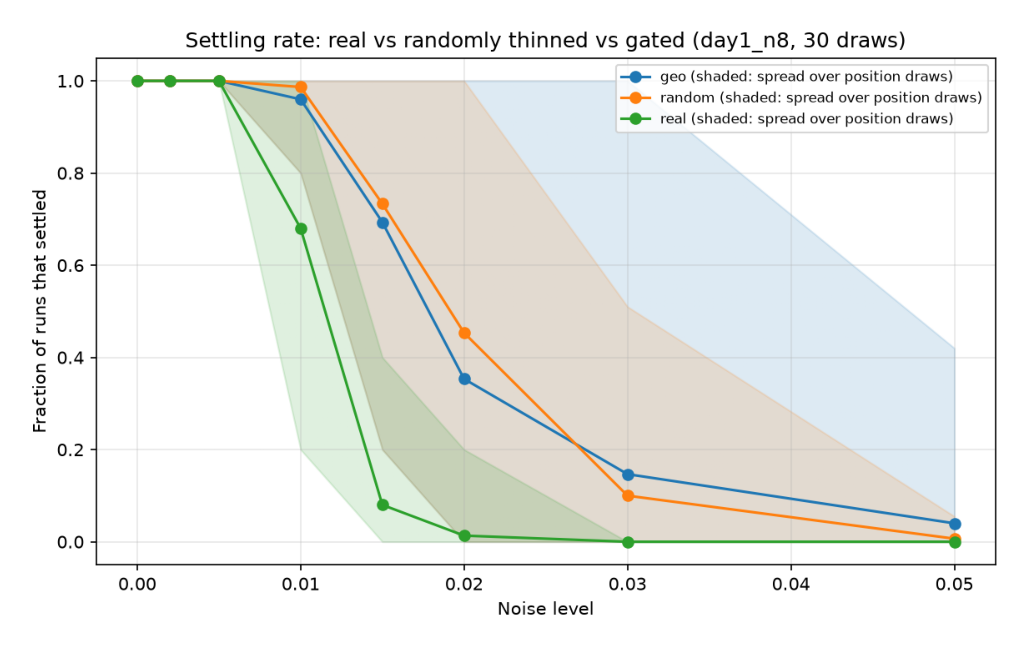

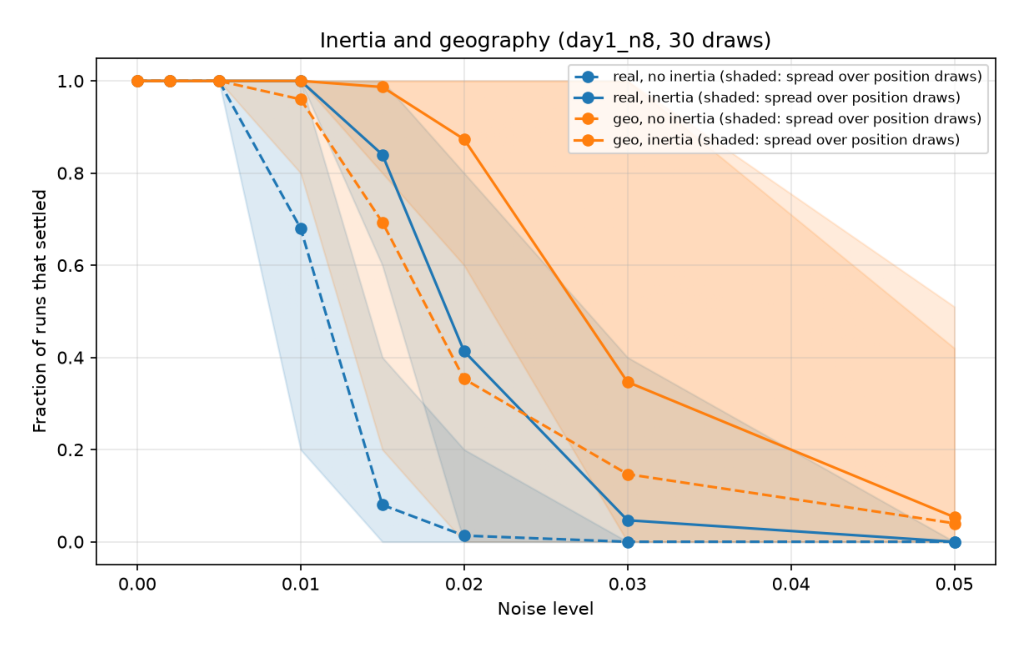

In [12]:
def show_geo(name, width=11):
    path = f"results_geo/{name}.png"
    if not os.path.exists(path):
        print(f"{path} not found: run `python src/run_geo_experiments.py` first")
        return
    img = plt.imread(path)
    plt.figure(figsize=(width, width * img.shape[0] / img.shape[1]))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


def tipping_table():
    rows = list(csv.DictReader(open("results_geo/tipping_points_geo.csv")))
    print(f"{'snapshot':<11}{'substrate':<11}{'no inertia':<18}with inertia")
    for tag in ("day1_n8", "day2_n8"):
        for kind in gex.SUBSTRATES:
            cell = {r["inertia"]: r["noise_at_50pct_settling"] for r in rows
                    if r["network"] == tag and r["substrate"] == kind}

            def fmt(value):
                return "never below 50%" if not value else f"{float(value):.4f}"

            print(f"{tag:<11}{kind:<11}{fmt(cell['False']):<18}{fmt(cell['True'])}")
        print()


tipping_table()
show_geo("noise_day1_n8", width=10)
show_geo("noise_inertia_day1_n8", width=10)

**Reading.** Inertia still raises the noise the network absorbs in every substrate, including the gated one, so the finding of section 5 survives the geography layer: day 1 rises from 0.0115 to 0.0190 on the real network and from 0.0178 to 0.0271 on the gated one, and day 2 from 0.0086 to 0.0165 and from 0.0124 to 0.0227. The other pattern is that both thinned substrates absorb more noise than the real snapshot, because thinning removes closed triangles and the dynamics only act inside a triangle. That effect of the relationship count is much larger than any difference between the two ways of thinning, which is what section 9 looks at.

## 9. What geography actually changes

At the same number of relationships the gated 

**Reading.** 

## 10. Discussion and limitations

* **Main finding of the original model.** Relationship inertia raises the random disruption a network can absorb before it stops settling. This held on two snapshots of different density and at three sign thresholds.
* **Mechanism.** The controls suggest the benefit comes from added resistance in general rather than from the specific mention-based assignment. This is a result of the test, not an assumption.
* **Outcome type.** Noise mainly decides whether the network settles, not what it settles into: when it settles, it is almost always a split into exactly two blocs.
* **Role of real data.** The real data provides realistic network structure and an empirical basis for inertia values. The real signs themselves were not shown to change outcomes.
* **What the geography extension adds.** The inertia result survives underneath a geography layer, in every substrate and on both snapshots. Geography has a structural signature that uniform thinning cannot reproduce, namely more closed triangles at the same relationship count. That signature does not translate into a more robust network, because a shock lands on a random edge of a randomly chosen triangle.
* **Limitations of the original model.** Each snapshot gives one fixed 8-country starting network, so results describe these snapshots. Tone comes from news wording and skews negative, so signs are a media-based proxy for relationships, not diplomatic fact. Mention volume is a rough proxy for how established a relationship is. Computation time grows quickly with network size, which limited us to small networks. Two days of data is a small replication.
* **Limitations of the geography extension.** The map is a random draw, so one draw is one sample: at noise 0.02 and a 60% gate the same arm ranges from 0.00 to 1.00 settled across draws, which is why every table reports the spread as well as the pooled rate. Positions and economic tiers are random rather than the real geography and economies of these countries. The gate can only remove relationships, so it cannot produce the new long-range relationships that a stronger economy is meant to unlock. Economic data does not exist in the snapshots, and the anonymisation script does not keep the code-to-label mapping, so a real economic column would have to be joined before anonymisation. Eight nations and two days remain a small replication.
* **Possible extensions.** More snapshots and larger networks; a second relationship layer such as trade; weighting influential countries; separating inertia from noise, since inertia currently resists both balance flips and noise flips; and letting the gate create long-range relationships rather than only removing them.

## 11. Reproducing everything
```bash
pip install -r requirements.txt
python -m pytest tests -q                                   # automated tests, including the geography layer
python src/run_experiments.py --quick --out results_quick    # 10-second check of the original model
python src/run_experiments.py --workers 4                    # full original experiments (about 10 minutes)
python src/run_geo_experiments.py --quick                    # fast check of the geography layer
python src/run_geo_experiments.py --draws 30 --repeats 5 --workers 4
python src/run_geo_experiments.py --only keep --draws 20 --repeats 4
```
See `README.md` for rebuilding the data from GDELT, and `README_GEO.md` for the rules of the geography layer and the full result tables.